# Classification WITHOUT Segmentation — 3 New Models

**Pipeline:** Raw image → Classify (no cropping)

Trains the **same three architectures** as notebook 07, but directly on raw TRAINTEST images.
This is the control group for the comparison.

| # | Model | Backbone | Save file |
|---|-------|----------|-----------|
| 1 | EfficientNet-B3 | EfficientNet-B3 | cls_noseg_efficientnetb3.pth |
| 2 | ResNet-50 | ResNet-50 | cls_noseg_resnet50.pth |
| 3 | ConvNeXt-Tiny | ConvNeXt-Tiny | cls_noseg_convnext.pth |

**Saves to:** `outputs/models/cls_noseg_*.pth`

## Cell 1: Imports & Configuration

In [1]:
import os, random, warnings, copy
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_curve, auc, classification_report)
import seaborn as sns

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

BASE       = r'C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry'
RAW_CLS    = os.path.join(BASE, 'TRAINTEST')   # raw images — no segmentation
MODEL_DIR  = os.path.join(BASE, 'outputs', 'models')
VIZ_DIR    = os.path.join(BASE, 'outputs', 'visualizations')
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(VIZ_DIR, exist_ok=True)

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE   = 224
BATCH_SIZE = 32

# Three-phase training (identical hyperparams to notebook 07 for fair comparison)
P1_EP, P1_LR = 10, 5e-4
P2_EP, P2_LR = 15, 1e-4
P3_EP, P3_LR = 15, 1e-5
WEIGHT_DECAY  = 5e-4
PATIENCE      = 10
MIXUP_ALPHA   = 0.2

CLASS_NAMES  = ['Infected', 'Non-infected']

plt.rcParams.update({
    'figure.facecolor':'#0d1117', 'axes.facecolor':'#161b22',
    'axes.edgecolor':'#30363d',   'axes.labelcolor':'#c9d1d9',
    'text.color':'#c9d1d9',       'xtick.color':'#8b949e',
    'ytick.color':'#8b949e',      'grid.color':'#21262d', 'font.size':11
})
ACCENT, GREEN, BLUE, YELLOW, PURPLE = '#e94560','#3fb950','#58a6ff','#e3b341','#bc8cff'

print(f'Device  : {DEVICE}')
print(f'Dataset : {RAW_CLS}  (raw, NO segmentation)')
print('Imports OK')

Device  : cpu
Dataset : C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\TRAINTEST  (raw, NO segmentation)
Imports OK


## Cell 2: Data Loaders (Raw Images)

In [2]:
train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.3),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.25, hue=0.1),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.1)),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(os.path.join(RAW_CLS, 'Train'), transform=train_tf)
val_ds   = datasets.ImageFolder(os.path.join(RAW_CLS, 'Valid'), transform=val_tf)
test_ds  = datasets.ImageFolder(os.path.join(RAW_CLS, 'test'),  transform=val_tf)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Classes : {train_ds.classes}')
print(f'Train   : {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
print('(These are the same raw TRAINTEST images — no cropping applied)')

Classes : ['Infected', 'Non-infected']
Train   : 700 | Val: 170 | Test: 152
(These are the same raw TRAINTEST images — no cropping applied)


## Cell 3: Model Architectures (identical to notebook 07)

In [3]:
def build_efficientnet_b3(num_classes=2):
    m  = models.efficientnet_b3(weights='DEFAULT')
    nf = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(nf, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(512, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True),
        nn.Dropout(p=0.2),
        nn.Linear(128, num_classes)
    )
    return m

def build_resnet50(num_classes=2):
    m  = models.resnet50(weights='DEFAULT')
    nf = m.fc.in_features
    m.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(nf, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(512, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True),
        nn.Dropout(p=0.2),
        nn.Linear(128, num_classes)
    )
    return m

def build_convnext_tiny(num_classes=2):
    m  = models.convnext_tiny(weights='DEFAULT')
    nf = m.classifier[2].in_features
    m.classifier[2] = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(nf, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(512, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True),
        nn.Dropout(p=0.2),
        nn.Linear(128, num_classes)
    )
    return m

# Save with noseg prefix to distinguish from notebook 07 models
CLASSIFIERS = {
    'EfficientNet-B3': (build_efficientnet_b3, 'cls_noseg_efficientnetb3.pth'),
    'ResNet-50'      : (build_resnet50,        'cls_noseg_resnet50.pth'),
    'ConvNeXt-Tiny'  : (build_convnext_tiny,   'cls_noseg_convnext.pth'),
}
print('Model builders defined:', list(CLASSIFIERS.keys()))

Model builders defined: ['EfficientNet-B3', 'ResNet-50', 'ConvNeXt-Tiny']


## Cell 4: Training Utilities

In [4]:
def mixup(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0)).to(x.device)
    return lam*x + (1-lam)*x[idx], y, y[idx], lam


def train_epoch(model, loader, optimizer, criterion, use_mixup=True):
    model.train()
    t_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        if use_mixup and random.random() > 0.5:
            imgs, la, lb, lam = mixup(imgs, labels, MIXUP_ALPHA)
            out  = model(imgs)
            loss = lam*criterion(out, la) + (1-lam)*criterion(out, lb)
            pred = out.argmax(1)
            correct += pred.eq(la if lam > 0.5 else lb).sum().item()
        else:
            out  = model(imgs)
            loss = criterion(out, labels)
            correct += out.argmax(1).eq(labels).sum().item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        t_loss += loss.item()
        total  += labels.size(0)
    return t_loss / len(loader), 100.0 * correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    v_loss, all_preds, all_labels, all_probs = 0.0, [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out   = model(imgs)
            v_loss += criterion(out, labels).item()
            probs  = torch.softmax(out, 1).cpu().numpy()
            all_preds.extend(probs.argmax(1))
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 0])
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return v_loss/len(loader), acc, f1, np.array(all_labels), np.array(all_probs)


def freeze_backbone(model, name):
    if 'EfficientNet' in name:
        for p in model.features.parameters(): p.requires_grad = False
    elif 'ResNet' in name:
        for n, p in model.named_parameters():
            if not n.startswith('fc'): p.requires_grad = False
    elif 'ConvNeXt' in name:
        for p in model.features.parameters(): p.requires_grad = False
        for p in model.avgpool.parameters():  p.requires_grad = False

def unfreeze_top(model, name):
    if 'EfficientNet' in name:
        for p in model.features[-3:].parameters(): p.requires_grad = True
    elif 'ResNet' in name:
        for p in model.layer4.parameters(): p.requires_grad = True
        for p in model.layer3.parameters(): p.requires_grad = True
    elif 'ConvNeXt' in name:
        for p in model.features[-2:].parameters(): p.requires_grad = True

def unfreeze_all(model):
    for p in model.parameters(): p.requires_grad = True

print('Training utilities defined.')

Training utilities defined.


## Cell 5: Three-Phase Training Function

In [5]:
def train_three_phase(model, model_name, save_path):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    best_f1, patience_ctr = 0.0, 0
    best_state  = None
    history     = {'train_loss':[], 'val_loss':[], 'val_acc':[], 'val_f1':[]}

    phases = [
        (P1_EP, P1_LR, True,  'Phase 1: Frozen backbone'),
        (P2_EP, P2_LR, True,  'Phase 2: Top blocks unfrozen'),
        (P3_EP, P3_LR, False, 'Phase 3: Full fine-tuning'),
    ]

    freeze_backbone(model, model_name)

    for ph_idx, (n_ep, lr, use_mixup, ph_name) in enumerate(phases):
        print(f'\n  [{ph_name}]  lr={lr}  epochs={n_ep}')
        if ph_idx == 1: unfreeze_top(model, model_name)
        if ph_idx == 2: unfreeze_all(model)

        tp = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'  Trainable params: {tp:,}')

        opt = torch.optim.AdamW(
            [p for p in model.parameters() if p.requires_grad],
            lr=lr, weight_decay=WEIGHT_DECAY)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_ep, eta_min=lr/100)
        patience_ctr = 0

        print(f'  {"Ep":>4} {"TLoss":>8} {"VLoss":>8} {"VAcc%":>7} {"VF1":>7}')
        print('  ' + '-'*40)

        for ep in range(1, n_ep + 1):
            tl, tacc             = train_epoch(model, train_dl, opt, criterion, use_mixup)
            vl, vacc, vf1, _, _  = eval_epoch(model, val_dl, criterion)
            sch.step()

            history['train_loss'].append(tl)
            history['val_loss'].append(vl)
            history['val_acc'].append(vacc)
            history['val_f1'].append(vf1)

            flag = ''
            if vf1 > best_f1:
                best_f1      = vf1
                best_state   = copy.deepcopy(model.state_dict())
                patience_ctr = 0
                torch.save({'model_state_dict': best_state,
                            'val_f1': vf1, 'val_acc': vacc}, save_path)
                flag = ' *'
            else:
                patience_ctr += 1

            print(f'  {ep:>4} {tl:>8.4f} {vl:>8.4f} {vacc*100:>7.2f} {vf1:>7.4f}{flag}')

            if patience_ctr >= PATIENCE:
                print(f'  Early stop at ep {ep}')
                break

    model.load_state_dict(best_state)
    print(f'\n  Best Val F1 : {best_f1:.4f}')
    print(f'  Saved       : {save_path}')
    return history, best_f1

print('Three-phase training function ready.')

Three-phase training function ready.


## Cell 6: Train All Three Classifiers

In [6]:
all_histories = {}
all_results   = {}

for model_name, (builder, save_file) in CLASSIFIERS.items():
    print(f'\n{"="*60}')
    print(f'  Training: {model_name}  (WITHOUT Segmentation)')
    print(f'{"="*60}')

    m         = builder().to(DEVICE)
    save_path = os.path.join(MODEL_DIR, save_file)
    hist, _   = train_three_phase(m, model_name, save_path)
    all_histories[model_name] = hist

    # --- Test evaluation ---
    ck = torch.load(save_path, map_location=DEVICE, weights_only=False)
    m.load_state_dict(ck['model_state_dict'])
    criterion = nn.CrossEntropyLoss()
    _, test_acc, test_f1, test_lbl, test_prob = eval_epoch(m, test_dl, criterion)
    fpr, tpr, _ = roc_curve(test_lbl, test_prob, pos_label=0)
    roc_auc = auc(fpr, tpr)

    all_results[model_name] = {
        'acc': test_acc, 'f1': test_f1, 'auc': roc_auc,
        'fpr': fpr, 'tpr': tpr, 'lbl': test_lbl, 'prob': test_prob,
    }
    print(f'\n  TEST -> Acc={test_acc*100:.2f}%  F1={test_f1:.4f}  AUC={roc_auc:.4f}')

print('\n\nAll classifiers trained!')


  Training: EfficientNet-B3  (WITHOUT Segmentation)

  [Phase 1: Frozen backbone]  lr=0.0005  epochs=10
  Trainable params: 854,146
    Ep    TLoss    VLoss   VAcc%     VF1
  ----------------------------------------
     1   0.6439   0.6022   80.59  0.8034 *
     2   0.5509   0.5931   76.47  0.7626
     3   0.5241   0.5439   82.35  0.8235 *
     4   0.5455   0.5313   82.94  0.8294 *
     5   0.5150   0.5503   82.35  0.8234
     6   0.5327   0.5643   79.41  0.7938
     7   0.4946   0.5981   74.71  0.7451
     8   0.5076   0.6093   75.29  0.7501
     9   0.4955   0.5840   77.65  0.7749
    10   0.5261   0.5801   77.06  0.7692

  [Phase 2: Top blocks unfrozen]  lr=0.0001  epochs=15
  Trainable params: 9,360,224
    Ep    TLoss    VLoss   VAcc%     VF1
  ----------------------------------------
     1   0.5415   0.6058   77.65  0.7754
     2   0.4772   0.6136   77.65  0.7749
     3   0.5115   0.5850   80.00  0.7993
     4   0.4318   0.5884   75.29  0.7507
     5   0.4593   0.5762   77.06 

## Cell 7: Training Curves

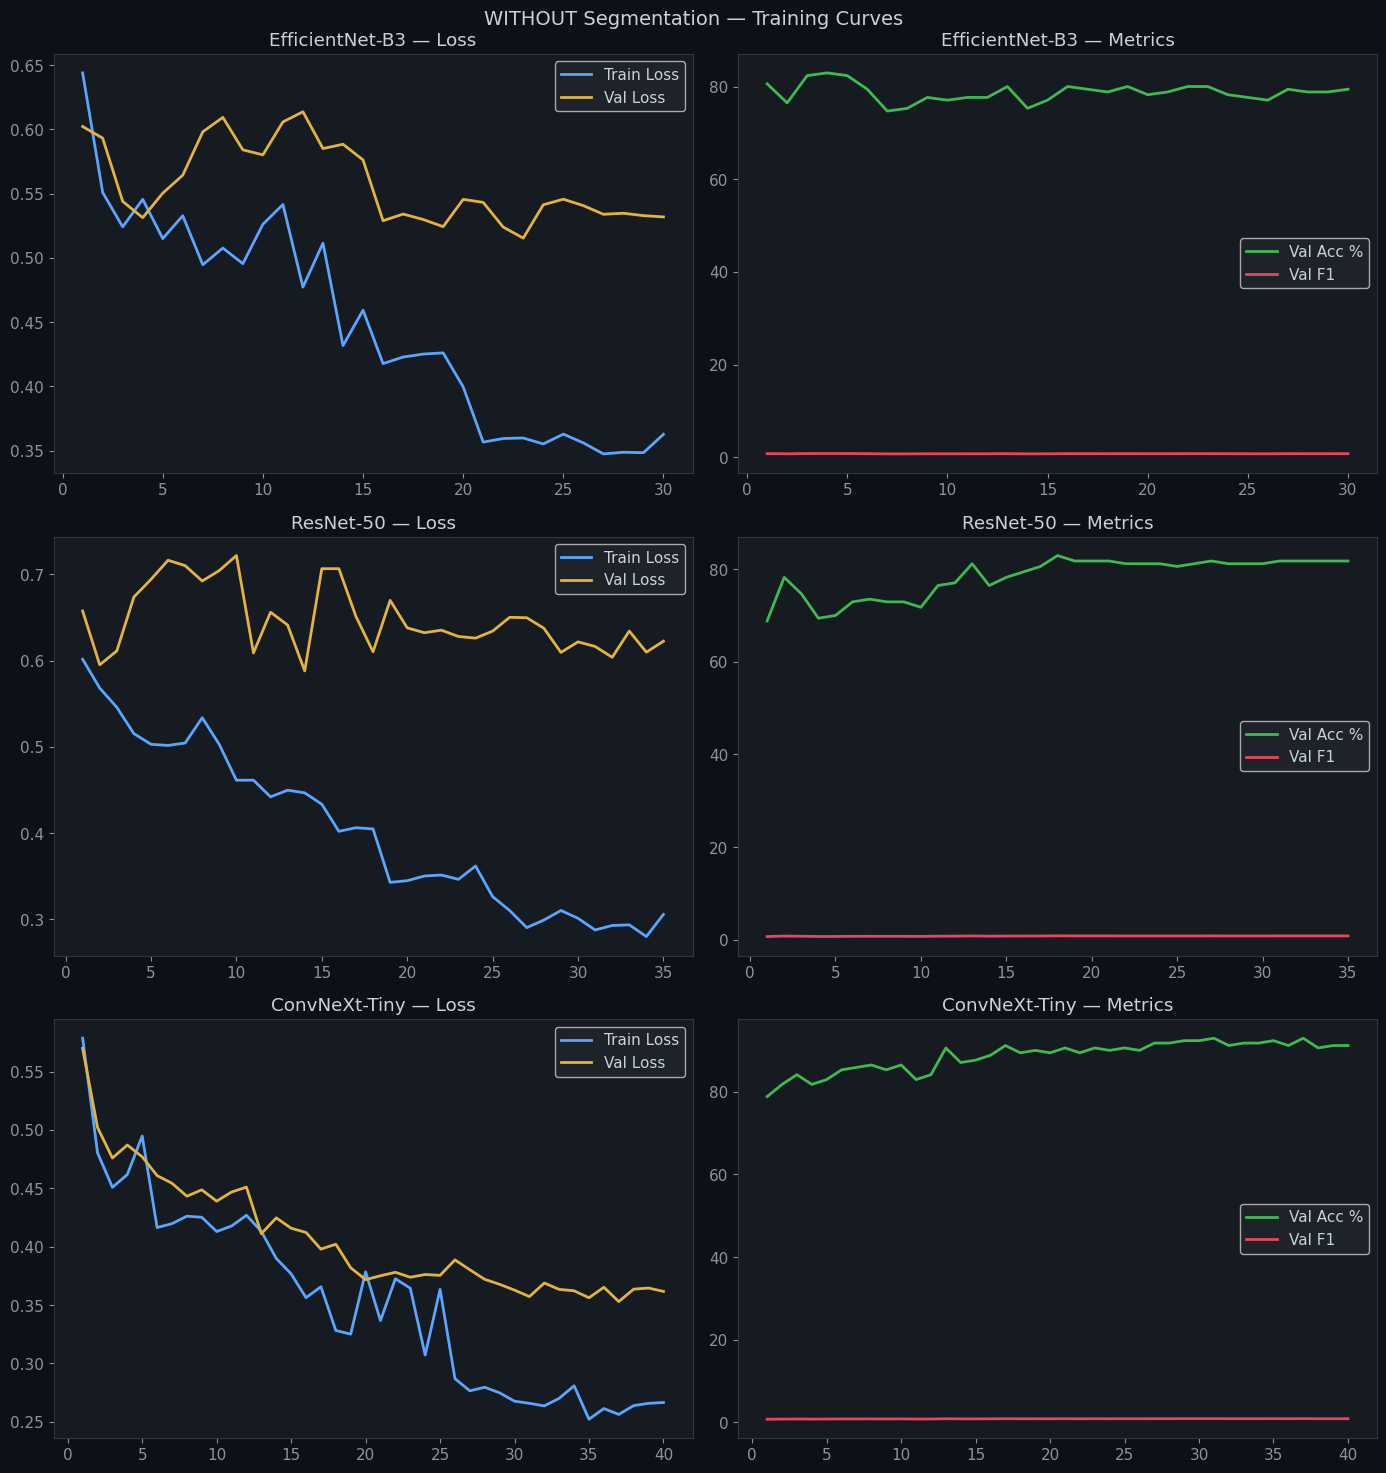

Saved -> outputs/visualizations/cls_noseg_training.png


In [7]:
fig, axes = plt.subplots(len(CLASSIFIERS), 2, figsize=(14, 5*len(CLASSIFIERS)), facecolor='#0d1117')
fig.suptitle('WITHOUT Segmentation — Training Curves', color='#c9d1d9', fontsize=14)

for row, (name, hist) in enumerate(all_histories.items()):
    ep = range(1, len(hist['train_loss'])+1)
    ax_l, ax_a = axes[row, 0], axes[row, 1]
    for ax in (ax_l, ax_a): ax.set_facecolor('#161b22'); ax.spines[:].set_edgecolor('#30363d')

    ax_l.plot(ep, hist['train_loss'], color=BLUE,   linewidth=2, label='Train Loss')
    ax_l.plot(ep, hist['val_loss'],   color=YELLOW,  linewidth=2, label='Val Loss')
    ax_l.set_title(f'{name} — Loss', color='#c9d1d9')
    ax_l.legend(facecolor='#21262d', labelcolor='#c9d1d9')

    ax_a.plot(ep, [v*100 for v in hist['val_acc']], color=GREEN,  linewidth=2, label='Val Acc %')
    ax_a.plot(ep, hist['val_f1'],                   color=ACCENT,  linewidth=2, label='Val F1')
    ax_a.set_title(f'{name} — Metrics', color='#c9d1d9')
    ax_a.legend(facecolor='#21262d', labelcolor='#c9d1d9')

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'cls_noseg_training.png'), dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved -> outputs/visualizations/cls_noseg_training.png')

## Cell 8: Results Summary


  CLASSIFICATION WITHOUT SEGMENTATION — TEST RESULTS
  Model                    Acc%       F1      AUC
--------------------------------------------------
  EfficientNet-B3         80.26   0.8023   0.8752
  ResNet-50               88.82   0.8880   0.9299
  ConvNeXt-Tiny           89.47   0.8947   0.9718
  Best model: ConvNeXt-Tiny  (F1=0.8947)


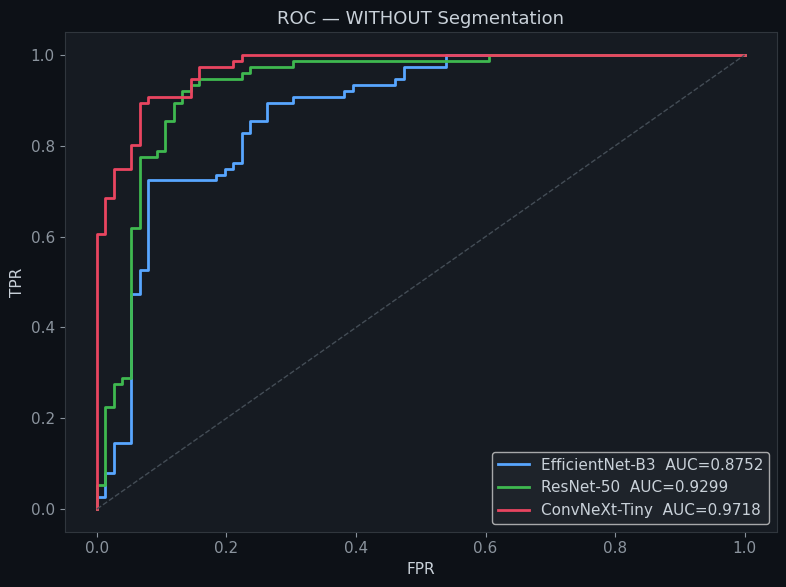

Saved -> outputs/visualizations/cls_noseg_roc.png


In [8]:
print(f'\n{"="*62}')
print(f'  CLASSIFICATION WITHOUT SEGMENTATION — TEST RESULTS')
print(f'{"="*62}')
print(f'  {"Model":<20} {"Acc%":>8} {"F1":>8} {"AUC":>8}')
print(f'{"-"*50}')
for name, r in all_results.items():
    print(f'  {name:<20} {r["acc"]*100:>8.2f} {r["f1"]:>8.4f} {r["auc"]:>8.4f}')
print(f'{"="*62}')
best = max(all_results, key=lambda k: all_results[k]['f1'])
print(f'  Best model: {best}  (F1={all_results[best]["f1"]:.4f})')

# ROC curves
fig, ax = plt.subplots(figsize=(8, 6), facecolor='#0d1117')
ax.set_facecolor('#161b22')
for (name, r), col in zip(all_results.items(), [BLUE, GREEN, ACCENT]):
    ax.plot(r['fpr'], r['tpr'], color=col, linewidth=2, label=f"{name}  AUC={r['auc']:.4f}")
ax.plot([0,1],[0,1], color='#444d56', linewidth=1, linestyle='--')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — WITHOUT Segmentation', color='#c9d1d9', fontsize=13)
ax.legend(facecolor='#21262d', labelcolor='#c9d1d9')
ax.spines[:].set_edgecolor('#30363d')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'cls_noseg_roc.png'), dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved -> outputs/visualizations/cls_noseg_roc.png')